# NEPSE RL Stochastic Pullback Engine


| Step | What |
|------|------|
| 1 | Load OHLCV data |
| 2 | Engineer features (stochastic, ATR, BBW, …) |
| 3 | Build Gymnasium environment |
| 4 | Train PPO agent |
| 5 | Deterministic evaluation |
| 6 | Metrics & trade ledger |
| 7 | Plots — equity curve, buy/sell signals |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import logging, pathlib, datetime, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

# ── Timestamped run folder (logs + plots all go here) ──
RUN_TS  = f"{datetime.datetime.now():%Y%m%d_%H%M%S}"
RUN_DIR = pathlib.Path(f"../runs/{RUN_TS}"); RUN_DIR.mkdir(parents=True, exist_ok=True)

# ── Logger setup (console + file in run folder) ──
log = logging.getLogger("nepserl")
log.setLevel(logging.DEBUG)
log.handlers.clear()

_fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%H:%M:%S")

_sh = logging.StreamHandler()
_sh.setLevel(logging.INFO)
_sh.setFormatter(_fmt)
log.addHandler(_sh)

LOG_FILE = RUN_DIR / "nepserl.log"
_fh = logging.FileHandler(LOG_FILE, encoding="utf-8")
_fh.setLevel(logging.DEBUG)
_fh.setFormatter(_fmt)
log.addHandler(_fh)

%matplotlib inline
DATA_DIR = pathlib.Path("../data/stocks")
n_csvs = len(list(DATA_DIR.glob("*.csv")))
log.info(f"Run dir : {RUN_DIR.resolve()}")
log.info(f"Data dir: {DATA_DIR.resolve()} — {n_csvs} CSVs found")

03:16:08 | INFO    | Run dir : C:\Users\krishna\Desktop\nepserl\runs\20260301_031608
03:16:08 | INFO    | Data dir: C:\Users\krishna\Desktop\nepserl\data\stocks — 636 CSVs found


---
## 1 — Load OHLCV Data

Read every CSV, build a MultiIndex `(Ticker, Feature)` DataFrame on a universal date axis,
and compute warm-up start dates (first valid + 200 trading days).

In [2]:
# ── Load all OHLCV CSVs into a MultiIndex DataFrame ──
MIN_ROWS, WARMUP = 250, 200
frames, skipped = {}, 0
for csv in sorted(DATA_DIR.glob("*.csv")):
    df = pd.read_csv(csv, parse_dates=["Timestamp"])
    if df.empty or len(df) < MIN_ROWS:
        skipped += 1; continue
    df = df.rename(columns={"Timestamp": "Date"})
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)
    df = df.set_index("Date").sort_index()
    df = df[~df.index.duplicated(keep="last")]
    if not {"Open","High","Low","Close","Volume"}.issubset(df.columns):
        skipped += 1; continue
    frames[csv.stem] = df[["Open","High","Low","Close","Volume"]]

log.info(f"Loaded {len(frames)} tickers, skipped {skipped} (< {MIN_ROWS} rows)")

# Build MultiIndex (Ticker, Feature) on a universal date axis
all_dates = sorted(set().union(*(f.index for f in frames.values())))
idx = pd.DatetimeIndex(all_dates, name="Date")
parts = {(tk, col): s.reindex(idx) for tk, df in frames.items() for col, s in df.items()}
master_df = pd.DataFrame(parts)
master_df.columns = pd.MultiIndex.from_tuples(master_df.columns, names=["Ticker","Feature"])
log.info(f"Master DataFrame: {master_df.shape}, date range {master_df.index.min().date()} → {master_df.index.max().date()}")

# Valid start dates = first ACTUAL trading day + WARMUP actual trading days
valid_start_dates = {}
for tk in master_df.columns.get_level_values("Ticker").unique():
    trading_days = master_df[tk].dropna(how="all").index
    if len(trading_days) > WARMUP:
        valid_start_dates[tk] = trading_days[WARMUP]
    else:
        valid_start_dates[tk] = trading_days[-1]

tickers = sorted(valid_start_dates.keys())
log.info(f"{len(tickers)} tickers with valid start dates (warmup={WARMUP} trading days)")

03:16:30 | INFO    | Loaded 378 tickers, skipped 258 (< 250 rows)
03:16:32 | INFO    | Master DataFrame: (6832, 1890), date range 1997-07-20 → 2026-02-25
03:16:32 | INFO    | 378 tickers with valid start dates (warmup=200 trading days)


In [3]:
# Preview raw OHLCV for a sample ticker
SAMPLE = tickers[0]
log.info(f"Sample ticker: {SAMPLE}")
master_df[SAMPLE].dropna().tail(8)

03:16:38 | INFO    | Sample ticker: ACLBSL


Feature,Open,High,Low,Close,Volume
Date,,,,,
2026-02-11,968.0,986.0,955.0,986.0,2724.0
2026-02-12,968.2,980.0,951.0,970.0,1332.0
2026-02-16,980.0,980.0,942.1,959.9,1356.0
2026-02-17,943.0,1017.0,943.0,1017.0,3672.0
2026-02-22,996.7,999.0,966.1,994.0,1717.0
2026-02-23,974.2,994.9,957.0,979.9,1469.0
2026-02-24,961.0,1050.0,945.0,978.0,4124.0
2026-02-25,958.5,977.0,958.5,977.0,22.0


In [6]:
# Warm-up dates
for t in tickers[:8]:
    log.info(f"  {t:>10s} → valid from {valid_start_dates[t].date()}")

03:17:16 | INFO    |       ACLBSL → valid from 2021-09-06
03:17:16 | INFO    |         ADBL → valid from 2012-06-06
03:17:16 | INFO    |          AHL → valid from 2024-02-01
03:17:16 | INFO    |         AHPC → valid from 2012-05-16
03:17:16 | INFO    |          AIL → valid from 2021-05-30
03:17:16 | INFO    |        AKJCL → valid from 2019-10-15
03:17:16 | INFO    |         AKPL → valid from 2018-03-11
03:17:16 | INFO    |        ALBSL → valid from 2020-01-06


In [7]:
# Generate feature data and sample one row for inspection
feat_df = compute_features(master_df, valid_start_dates)

# Get actual feature values for debugging
sample_row = feat_df[SAMPLE].dropna(how='all').iloc[500]
print("SAMPLE FEATURE ROW (scalar magnitudes):")
print("="*50)
for col, val in sample_row.to_dict().items():
    print(f"{col:>20s}: {val:+8.6f}")

print("\nNORMALIZATION ISSUE CONFIRMED:")
print("pct_k, pct_d: [0.0, 1.0] range")  
print("natr, bbw, d_low: [-3.0, +3.0] Z-scored range")
print("This scale mismatch causes gradient instabilities!")

03:18:47 | INFO    | Computing features for 378 tickers...
03:19:01 | INFO    | Feature engineering done — shape (6832, 6048), 16 features per ticker


SAMPLE FEATURE ROW (scalar magnitudes):
                open: +700.100000
                high: +722.000000
                 low: +700.100000
               close: +720.000000
              volume: +245.000000
               sma50: +722.764000
              sma200: +883.697986
         macro_trend: +0.000000
 protected_swing_low: +688.200000
               d_low: -0.690592
               pct_k: +0.540821
               pct_d: +0.569163
             delta_k: -0.039179
               atr14: +18.646412
                natr: -1.437426
                 bbw: -1.093761

NORMALIZATION ISSUE CONFIRMED:
pct_k, pct_d: [0.0, 1.0] range
natr, bbw, d_low: [-3.0, +3.0] Z-scored range
This scale mismatch causes gradient instabilities!


---
## 2 — Feature Engineering (standalone)

All indicator functions defined right here. No look-ahead bias —
everything is computed from historical data only.

| Feature | Description |
|---------|-------------|
| `pct_k`, `pct_d` | Stochastic Oscillator (14,3) scaled [0,1] |
| `natr` | Normalised ATR(14) |
| `bbw` | Bollinger Bandwidth (20,2) |
| `d_low` | Distance to protected swing low |
| `sma50`, `sma200` | Moving averages |
| `macro_trend` | 1 if SMA50 > SMA200 |
| `atr14` | Raw ATR(14) for Chandelier-Exit |
| `protected_swing_low` | Rolling 60-day structural floor |

In [4]:
# ── Indicator primitives ──

def _sma(s, n):
    return s.rolling(n, min_periods=n).mean()

def _true_range(high, low, close):
    prev_c = close.shift(1)
    return pd.concat([high - low, (high - prev_c).abs(), (low - prev_c).abs()], axis=1).max(axis=1)

def _atr(high, low, close, n=14):
    return _true_range(high, low, close).ewm(span=n, min_periods=n, adjust=False).mean()

def _stochastic(high, low, close, k_period=14, d_period=3):
    lowest  = low.rolling(k_period, min_periods=k_period).min()
    highest = high.rolling(k_period, min_periods=k_period).max()
    raw_k = 100.0 * (close - lowest) / (highest - lowest + 1e-10)
    pct_k = raw_k.rolling(d_period, min_periods=d_period).mean()
    pct_d = pct_k.rolling(d_period, min_periods=d_period).mean()
    return pct_k, pct_d

def _bollinger_bandwidth(close, n=20, num_std=2.0):
    sma = _sma(close, n)
    std = close.rolling(n, min_periods=n).std()
    return ((sma + num_std * std) - (sma - num_std * std)) / (sma + 1e-10)

def _protected_swing_low(low, window=60):
    return low.rolling(window, min_periods=window).min()

log.info("Indicator functions defined")

03:16:43 | INFO    | Indicator functions defined


In [5]:
def compute_features(master_df, valid_start_dates):
    """Build all features from raw OHLCV. Returns MultiIndex (Ticker, Feature) DataFrame.

    Key: compute indicators on each ticker's own trading days (no NaN gaps)
    THEN assemble into the universal date axis. This avoids rolling windows
    being poisoned by NaN rows from non-trading days.
    """
    all_tickers = master_df.columns.get_level_values("Ticker").unique()
    log.info(f"Computing features for {len(all_tickers)} tickers...")
    pieces = {}

    for ticker in all_tickers:
        # ── Drop non-trading days so rolling windows see continuous data ──
        raw = master_df[ticker].dropna(how="all")
        o, h, l, c, v = raw["Open"], raw["High"], raw["Low"], raw["Close"], raw["Volume"]

        # Pass-through
        pieces[(ticker, "open")]   = o
        pieces[(ticker, "high")]   = h
        pieces[(ticker, "low")]    = l
        pieces[(ticker, "close")]  = c
        pieces[(ticker, "volume")] = v

        # Trend & structure
        sma50  = _sma(c, 50)
        sma200 = _sma(c, 200)
        psl    = _protected_swing_low(l, 60)
        pieces[(ticker, "sma50")]  = sma50
        pieces[(ticker, "sma200")] = sma200
        pieces[(ticker, "macro_trend")] = (sma50 > sma200).astype(np.float32)
        pieces[(ticker, "protected_swing_low")] = psl
        pieces[(ticker, "d_low")] = (c - psl) / (c + 1e-10)

        # Momentum (pullback vector)
        pct_k, pct_d = _stochastic(h, l, c)
        pieces[(ticker, "pct_k")]   = pct_k / 100.0
        pieces[(ticker, "pct_d")]   = pct_d / 100.0
        pieces[(ticker, "delta_k")] = (pct_k - pct_k.shift(1)) / 100.0

        # Volatility (regime filter)
        atr14 = _atr(h, l, c, 14)
        pieces[(ticker, "atr14")] = atr14
        pieces[(ticker, "natr")]  = atr14 / (c + 1e-10)
        pieces[(ticker, "bbw")]   = _bollinger_bandwidth(c, 20, 2.0)

    # Assemble — each piece lives on its own trading-day index;
    # pandas unions them into the universal date axis automatically
    feat_df = pd.DataFrame(pieces)
    feat_df.columns = pd.MultiIndex.from_tuples(feat_df.columns, names=["Ticker", "Feature"])
    feat_df = feat_df.sort_index()

    # Rolling 252-day Z-score on selected features (also on clean data)
    for ticker in all_tickers:
        for col in ["natr", "bbw", "d_low"]:
            key = (ticker, col)
            if key not in feat_df.columns:
                continue
            clean = feat_df[key].dropna()
            rm = clean.rolling(252, min_periods=252).mean()
            rs = clean.rolling(252, min_periods=252).std()
            feat_df[key] = ((clean - rm) / (rs + 1e-8)).clip(-3, 3)

    n_features = feat_df.columns.get_level_values("Feature").nunique()
    log.info(f"Feature engineering done — shape {feat_df.shape}, {n_features} features per ticker")
    return feat_df

log.info("compute_features() defined")

03:16:48 | INFO    | compute_features() defined


In [80]:
# Inspect features for sample ticker
log.info(f"Features for {SAMPLE} (last 8 rows)")
feat_df[SAMPLE].dropna(how="all").tail(8)

17:24:19 | INFO    | Features for ACLBSL (last 8 rows)


Feature,open,high,low,close,volume,sma50,sma200,macro_trend,protected_swing_low,d_low,pct_k,pct_d,delta_k,atr14,natr,bbw
Date,,,,,,,,,,,,,,,,
2026-02-12,968.2,980.0,951.0,970.0,1332.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,42.804694,NaN,NaN
2026-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,42.804694,NaN,NaN
2026-02-16,980.0,980.0,942.1,959.9,1356.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,42.065293,NaN,NaN
2026-02-17,943.0,1017.0,943.0,1017.0,3672.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,46.323254,NaN,NaN
2026-02-22,996.7,999.0,966.1,994.0,1717.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,46.933487,NaN,NaN
2026-02-23,974.2,994.9,957.0,979.9,1469.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,45.729022,NaN,NaN
2026-02-24,961.0,1050.0,945.0,978.0,4124.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,53.631819,NaN,NaN
2026-02-25,958.5,977.0,958.5,977.0,22.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,49.080910,NaN,NaN


17:24:20 | INFO    | Saved features_ACLBSL.png


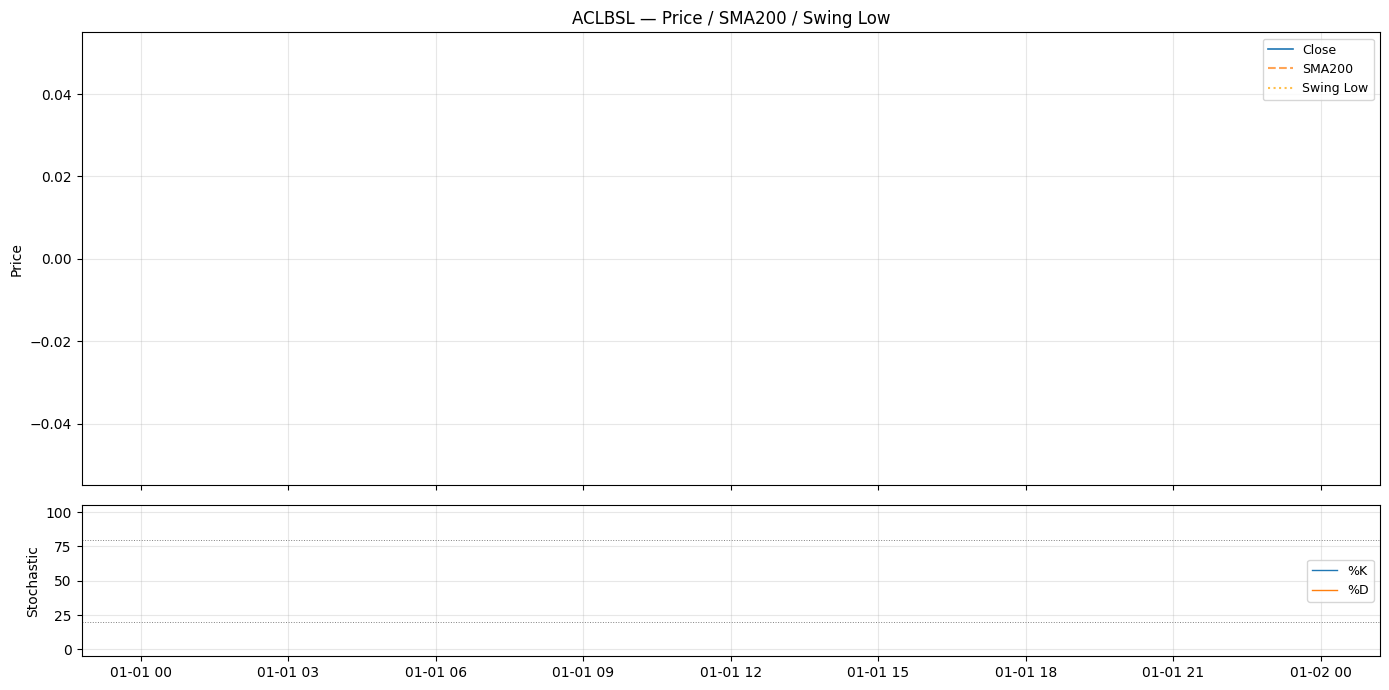

In [81]:
# Plot: Close + SMA200 + Stochastic
tk_data = feat_df[SAMPLE].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(tk_data.index, tk_data["close"], label="Close", lw=1.2)
ax1.plot(tk_data.index, tk_data["sma200"], label="SMA200", ls="--", alpha=0.7)
ax1.plot(tk_data.index, tk_data["protected_swing_low"], label="Swing Low",
         ls=":", alpha=0.7, color="orange")
ax1.set_ylabel("Price"); ax1.set_title(f"{SAMPLE} — Price / SMA200 / Swing Low")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.plot(tk_data.index, tk_data["pct_k"] * 100, label="%K", lw=1)
ax2.plot(tk_data.index, tk_data["pct_d"] * 100, label="%D", lw=1)
ax2.axhline(20, color="gray", ls=":", lw=0.7)
ax2.axhline(80, color="gray", ls=":", lw=0.7)
ax2.set_ylabel("Stochastic"); ax2.set_ylim(-5, 105)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(RUN_DIR / f"features_{SAMPLE}.png", dpi=150, bbox_inches="tight")
log.info(f"Saved features_{SAMPLE}.png")
plt.show()

---
## 3 — Gymnasium Environment (standalone)

- **Action**: `Discrete(2)` — 0 = Cash, 1 = Long
- **Obs**: 7-dim `[%K, %D, NATR, BBW, D_low, position, dist_to_TSL]`
- **Chandelier-Exit TSL**: forced liquidation when low breaches trailing stop
- **Reward**: log-return while long, friction on transitions, opportunity cost while in cash

In [82]:
class NepseEnv(gym.Env):
    """NEPSE stochastic-pullback RL environment."""

    OBS_FEATURES = ["pct_k", "pct_d", "natr", "bbw", "d_low"]
    TAU = 0.015             # transaction friction
    ATR_MULT = 2.5          # chandelier-exit multiplier
    FORCED_EXIT_PENALTY = 0.05
    OC_SCALE = 0.5          # opportunity-cost scale
    CASH_FRICTION = 0.001

    def __init__(self, feat_df, valid_start_dates, episode_length=252, seed=None):
        super().__init__()
        self.feat_df = feat_df
        self.valid_start_dates = valid_start_dates
        self.tickers = sorted(valid_start_dates.keys())
        self.episode_length = episode_length
        self.dates = feat_df.index

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(7,), dtype=np.float32)
        self._rng = np.random.default_rng(seed)

        # Episode state
        self._ticker = ""
        self._start_idx = 0
        self._step = 0
        self._position = 0
        self._entry_price = 0.0
        self._hh = 0.0
        self._tsl = 0.0
        self._pv = 1.0
        self._buys = 0
        self._sells = 0
        self._forced = 0

        # Pre-cache numpy arrays
        self._cache = {}
        needed = self.OBS_FEATURES + ["close", "high", "low", "atr14", "protected_swing_low", "open", "sma200"]
        for tk in self.tickers:
            c = {}
            for f in needed:
                try:
                    c[f] = feat_df[(tk, f)].values.astype(np.float64)
                except KeyError:
                    c[f] = np.full(len(self.dates), np.nan)
            self._cache[tk] = c

        log.info(f"NepseEnv init — {len(self.tickers)} tickers, ep_len={episode_length}, obs={self.observation_space.shape}")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        self._ticker = self._rng.choice(self.tickers)
        vs = self.valid_start_dates[self._ticker]
        vs_idx = int(np.searchsorted(self.dates, vs))
        last = len(self.dates) - self.episode_length
        if last <= vs_idx:
            vs_idx = max(0, last - 1)
        self._start_idx = int(self._rng.integers(vs_idx, max(vs_idx + 1, last)))
        self._step = 0
        self._position = 0
        self._entry_price = 0.0
        self._hh = 0.0
        self._tsl = 0.0
        self._pv = 1.0
        self._buys = 0
        self._sells = 0
        self._forced = 0
        start_date = self.dates[self._start_idx]
        log.debug(f"ENV reset — ticker={self._ticker}, start={start_date.date()}, idx={self._start_idx}")
        return self._obs(), self._info()

    def step(self, action):
        c = self._cache[self._ticker]
        idx = self._start_idx + self._step
        close_t  = c["close"][idx]
        high_t   = c["high"][idx]
        low_t    = c["low"][idx]
        atr_t    = c["atr14"][idx]
        psl_t    = c["protected_swing_low"][idx]
        prev_c   = c["close"][max(idx - 1, 0)]

        if np.isnan(close_t) or np.isnan(prev_c):
            self._step += 1
            t = self._step >= self.episode_length
            tr = (self._start_idx + self._step) >= len(self.dates) - 1
            return self._obs(), 0.0, t, tr, self._info()

        for v in [atr_t, psl_t, high_t, low_t]:
            if np.isnan(atr_t): atr_t = 0.0
            if np.isnan(psl_t): psl_t = 0.0
            if np.isnan(high_t): high_t = close_t
            if np.isnan(low_t): low_t = close_t

        reward = 0.0
        forced = False

        if self._position == 0 and action == 1:          # BUY
            self._position = 1
            self._entry_price = close_t
            self._hh = close_t
            self._tsl = self._hh - self.ATR_MULT * atr_t
            reward -= self.TAU
            self._buys += 1
            log.debug(f"  BUY  step={self._step} close={close_t:.2f} tsl={self._tsl:.2f}")

        elif self._position == 1 and action == 1:        # HOLD LONG
            self._hh = max(self._hh, high_t)
            self._tsl = max(self._tsl, self._hh - self.ATR_MULT * atr_t)
            if low_t <= self._tsl or low_t <= psl_t:     # FORCED EXIT
                forced = True
                self._position = 0
                exit_p = min(max(self._tsl, psl_t), prev_c)
                lr = np.log(exit_p / (prev_c + 1e-10))
                reward += lr - self.TAU - self.FORCED_EXIT_PENALTY
                self._pv *= np.exp(lr - self.TAU)
                self._entry_price = 0.0
                self._forced += 1
                log.debug(f"  FORCED EXIT step={self._step} exit_p={exit_p:.2f} low={low_t:.2f} tsl={self._tsl:.2f}")
            else:
                lr = np.log(close_t / (prev_c + 1e-10))
                reward += lr
                self._pv *= np.exp(lr)

        elif self._position == 1 and action == 0:        # SELL
            self._position = 0
            lr = np.log(close_t / (prev_c + 1e-10))
            reward += lr - self.TAU
            self._pv *= np.exp(lr - self.TAU)
            self._entry_price = 0.0
            self._sells += 1
            log.debug(f"  SELL step={self._step} close={close_t:.2f} pv={self._pv:.4f}")

        else:                                            # HOLD CASH
            delta = np.log(close_t / (prev_c + 1e-10))
            reward -= delta * self.OC_SCALE if delta > 0 else self.CASH_FRICTION

        self._step += 1
        terminated = self._step >= self.episode_length
        truncated  = (self._start_idx + self._step) >= len(self.dates) - 1
        info = self._info()
        info["forced_liquidation"] = forced
        if np.isnan(reward) or np.isinf(reward):
            reward = 0.0

        if terminated or truncated:
            log.debug(f"  EP END {self._ticker} — pv={self._pv:.4f} buys={self._buys} sells={self._sells} forced={self._forced}")

        return self._obs(), float(reward), terminated, truncated, info

    def _obs(self):
        c = self._cache[self._ticker]
        idx = min(self._start_idx + self._step, len(self.dates) - 1)
        obs = np.zeros(7, dtype=np.float32)
        for i, f in enumerate(self.OBS_FEATURES):
            v = c[f][idx]
            obs[i] = 0.0 if np.isnan(v) else float(v)
        obs[5] = float(self._position)
        if self._position == 1:
            cl = c["close"][idx]
            obs[6] = float((cl - self._tsl) / (cl + 1e-10)) if not np.isnan(cl) and cl != 0 else 0.0
        return np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)

    def _info(self):
        c = self._cache[self._ticker]
        idx = min(self._start_idx + self._step, len(self.dates) - 1)
        return {
            "ticker": self._ticker,
            "date": self.dates[idx],
            "close": float(c["close"][idx]),
            "action": -1,
            "tsl_level": float(self._tsl) if self._position == 1 else np.nan,
            "portfolio_value": float(self._pv),
            "position": self._position,
        }

log.info("NepseEnv defined")

17:24:20 | INFO    | NepseEnv defined


In [83]:
# Quick sanity check — one reset + step
env = NepseEnv(feat_df, valid_start_dates, episode_length=252, seed=42)

obs, info = env.reset()
log.info(f"Reset — obs={np.array2string(obs, precision=4)}, ticker={info['ticker']}, date={info['date'].date()}")

obs2, reward, term, trunc, info2 = env.step(1)  # BUY
log.info(f"After BUY — reward={reward:+.6f}, position={obs2[5]:.0f}, pv={info2['portfolio_value']:.4f}")

17:24:20 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:24:20 | INFO    | Reset — obs=[0. 0. 0. 0. 0. 0. 0.], ticker=CHDC, date=2024-07-28
17:24:20 | INFO    | After BUY — reward=+0.000000, position=0, pv=1.0000


---
## 4 — PPO Training (standalone)

Using Stable-Baselines3 PPO. Set `TOTAL_TIMESTEPS` to 50k for a quick test,
500k+ for meaningful results.

In [84]:
class RewardTracker(BaseCallback):
    """Collects episode rewards and training losses during PPO training."""
    def __init__(self):
        super().__init__(verbose=0)
        self.ep_timesteps = []
        self.ep_rewards = []
        self.update_ts = []
        self.policy_losses = []
        self.value_losses = []
        self.entropy_losses = []
        self._ep_count = 0

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_timesteps.append(self.num_timesteps)
                self.ep_rewards.append(info["episode"]["r"])
                self._ep_count += 1
                if self._ep_count % 50 == 0:
                    avg = np.mean(self.ep_rewards[-50:])
                    log.info(f"Training — ep {self._ep_count}, ts {self.num_timesteps}, avg_reward(50)={avg:+.4f}")
        return True

    def _on_rollout_end(self):
        try:
            vals = self.model.logger.name_to_value
            self.update_ts.append(self.num_timesteps)
            self.policy_losses.append(vals.get("train/policy_gradient_loss", 0.0))
            self.value_losses.append(vals.get("train/value_loss", 0.0))
            self.entropy_losses.append(vals.get("train/entropy_loss", 0.0))
        except Exception:
            pass

log.info("RewardTracker defined")

17:24:20 | INFO    | RewardTracker defined


In [85]:
TOTAL_TIMESTEPS = 500_000   # train on all tickers
N_ENVS = 4
SEED = 42

log.info(f"Training config — timesteps={TOTAL_TIMESTEPS}, n_envs={N_ENVS}, seed={SEED}")

def make_env(seed):
    def _init():
        return Monitor(NepseEnv(feat_df, valid_start_dates, episode_length=252, seed=seed))
    return _init

vec_env  = DummyVecEnv([make_env(SEED + i) for i in range(N_ENVS)])
eval_env = DummyVecEnv([make_env(SEED + 999)])

model = PPO(
    "MlpPolicy", vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.05,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    device="auto",
    verbose=0,
    policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])),
)

log.info(f"PPO model created — device={model.device}, policy_arch=[128,128]")

tracker = RewardTracker()
log.info("Starting training...")

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[tracker],
    progress_bar=True,
)

vec_env.close()
eval_env.close()
log.info(f"Training complete — {len(tracker.ep_rewards)} episodes, final avg_reward={np.mean(tracker.ep_rewards[-20:]):+.4f}")

17:24:20 | INFO    | Training config — timesteps=500000, n_envs=4, seed=42
17:24:21 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:24:21 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:24:21 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:24:22 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:24:22 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:24:22 | INFO    | PPO model created — device=cpu, policy_arch=[128,128]
17:24:22 | INFO    | Starting training...
17:24:28 | INFO    | Training — ep 50, ts 13104, avg_reward(50)=-1.2211
17:24:35 | INFO    | Training — ep 100, ts 25200, avg_reward(50)=-1.1635
17:24:41 | INFO    | Training — ep 150, ts 38304, avg_reward(50)=-1.1282
17:24:48 | INFO    | Training — ep 200, ts 50400, avg_reward(50)=-1.1265
17:24:54 | INFO    | Training — ep 250, ts 63504, avg_reward(50)=-0.9812
17:25:01 | INFO    | Training — ep 300, ts 75600, avg_reward(50)=-0.8957
17:25:07 | INFO 

17:28:45 | INFO    | Training complete — 2012 episodes, final avg_reward=-0.5732


17:28:45 | INFO    | Saved training_episode_reward.png


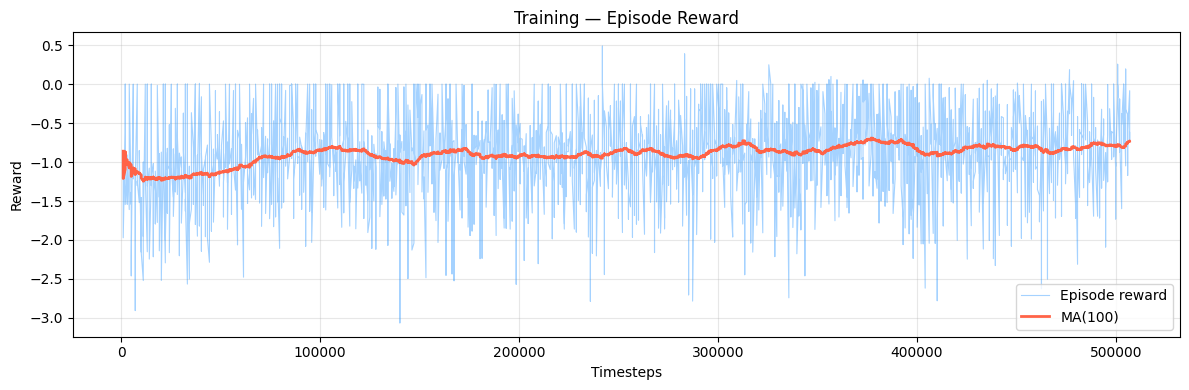

In [86]:
# Training reward curve
if tracker.ep_rewards:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(tracker.ep_timesteps, tracker.ep_rewards, alpha=0.4, lw=0.8, color="dodgerblue", label="Episode reward")
    if len(tracker.ep_rewards) > 10:
        w = max(5, len(tracker.ep_rewards) // 20)
        sm = pd.Series(tracker.ep_rewards).rolling(w, min_periods=1).mean()
        ax.plot(tracker.ep_timesteps, sm, color="tomato", lw=2, label=f"MA({w})")
    ax.set_xlabel("Timesteps"); ax.set_ylabel("Reward")
    ax.set_title("Training — Episode Reward")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
    fig.savefig(RUN_DIR / "training_episode_reward.png", dpi=150, bbox_inches="tight")
    log.info("Saved training_episode_reward.png")
    plt.show()

17:28:46 | INFO    | Saved training_losses.png


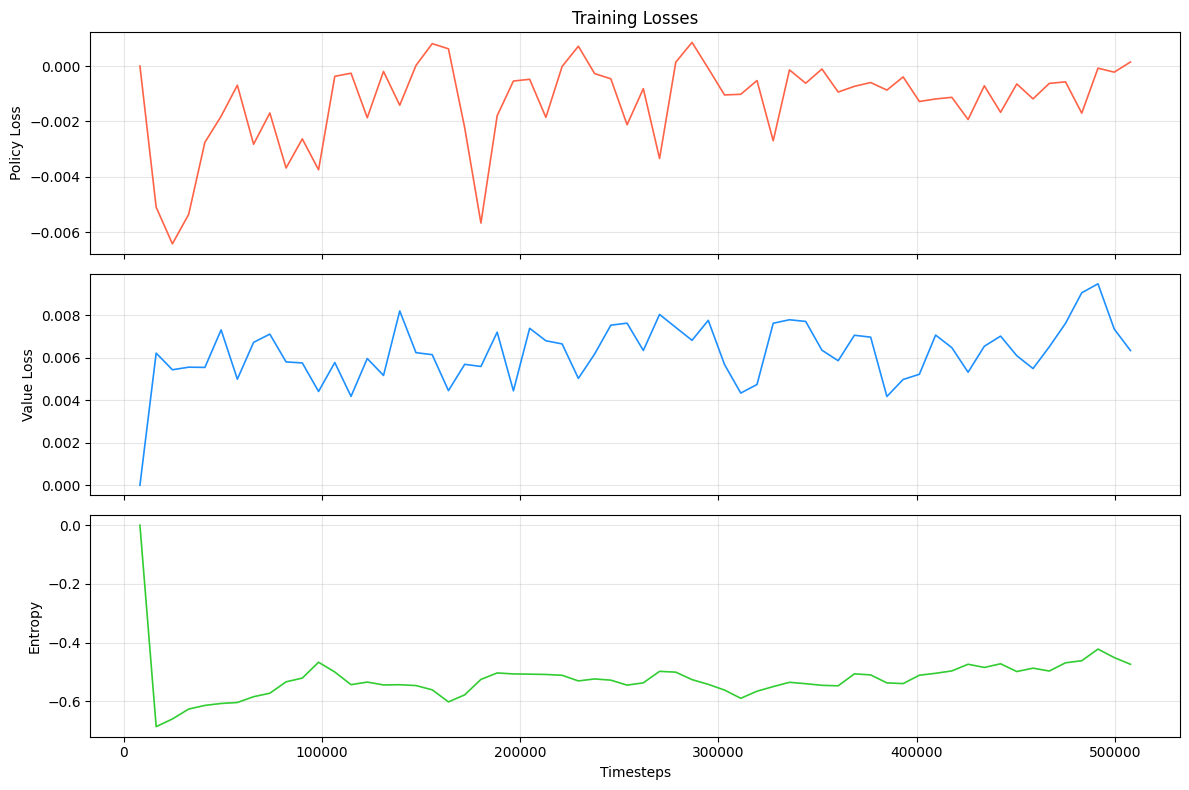

In [87]:
# Training loss curves
if tracker.update_ts:
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(tracker.update_ts, tracker.policy_losses, color="tomato", lw=1.2)
    axes[0].set_ylabel("Policy Loss"); axes[0].set_title("Training Losses"); axes[0].grid(True, alpha=0.3)
    axes[1].plot(tracker.update_ts, tracker.value_losses, color="dodgerblue", lw=1.2)
    axes[1].set_ylabel("Value Loss"); axes[1].grid(True, alpha=0.3)
    axes[2].plot(tracker.update_ts, tracker.entropy_losses, color="limegreen", lw=1.2)
    axes[2].set_ylabel("Entropy"); axes[2].set_xlabel("Timesteps"); axes[2].grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(RUN_DIR / "training_losses.png", dpi=150, bbox_inches="tight")
    log.info("Saved training_losses.png")
    plt.show()

---
## 5 — Deterministic Evaluation

In [88]:
def run_episode(model, feat_df, valid_start_dates, ticker=None, episode_length=252, seed=123):
    """Roll-out the model deterministically on one ticker. Returns a trajectory DataFrame."""
    env = NepseEnv(feat_df, valid_start_dates, episode_length=episode_length, seed=seed)
    obs, info = env.reset()

    if ticker is not None:
        env._ticker = ticker
        vs = valid_start_dates[ticker]
        env._start_idx = int(np.searchsorted(env.dates, vs))
        env._step = 0
        env._position = 0
        env._entry_price = 0.0
        env._hh = 0.0
        env._tsl = 0.0
        env._pv = 1.0
        obs = env._obs()
        info = env._info()

    log.info(f"Eval episode — ticker={env._ticker}, start={env.dates[env._start_idx].date()}, len={episode_length}")

    records = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)
        info["action"] = action
        records.append(info.copy())
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    info["action"] = -1
    records.append(info.copy())

    traj = pd.DataFrame(records)
    final_pv = traj["portfolio_value"].iloc[-1]
    n_buys = (traj["action"] == 1).sum()
    log.info(f"Eval done — {env._ticker}: pv={final_pv:.4f}, steps={len(traj)}, buys={n_buys}")
    return traj

log.info("run_episode() defined")

17:28:46 | INFO    | run_episode() defined


In [89]:
EVAL_TICKER = SAMPLE
traj = run_episode(model, feat_df, valid_start_dates, ticker=EVAL_TICKER)

log.info(f"Ticker: {traj['ticker'].iloc[0]}, period: {traj['date'].iloc[0].date()} → {traj['date'].iloc[-1].date()}")
log.info(f"Final PV: {traj['portfolio_value'].iloc[-1]:.6f}")
traj.head(10)

17:28:46 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:28:46 | INFO    | Eval episode — ticker=ACLBSL, start=2021-09-06, len=252
17:28:47 | INFO    | Eval done — ACLBSL: pv=0.9843, steps=253, buys=48
17:28:47 | INFO    | Ticker: ACLBSL, period: 2021-09-06 → 2022-08-01
17:28:47 | INFO    | Final PV: 0.984317


,ticker,date,close,action,tsl_level,portfolio_value,position,forced_liquidation
0,ACLBSL,2021-09-06,1287.4102,0,NaN,1.0,0,NaN
1,ACLBSL,2021-09-07,1262.3307,0,NaN,1.0,0,False
2,ACLBSL,2021-09-08,1262.3307,0,NaN,1.0,0,False
3,ACLBSL,2021-09-09,1254.8069,0,NaN,1.0,0,False
4,ACLBSL,2021-09-12,1275.7064,0,NaN,1.0,0,False
5,ACLBSL,2021-09-13,1270.6906,0,NaN,1.0,0,False
6,ACLBSL,2021-09-14,1269.8545,0,NaN,1.0,0,False
7,ACLBSL,2021-09-15,1256.4788,0,NaN,1.0,0,False
8,ACLBSL,2021-09-16,1253.1349,0,NaN,1.0,0,False
9,ACLBSL,2021-09-20,1192.9443,0,NaN,1.0,0,False


In [90]:
# Action distribution
ac = traj["action"].value_counts()
log.info(f"Actions — Cash(0):{ac.get(0,0)}, Long(1):{ac.get(1,0)}, End(-1):{ac.get(-1,0)}")

17:28:47 | INFO    | Actions — Cash(0):204, Long(1):48, End(-1):1


---
## 6 — Metrics & Trade Ledger

In [91]:
def build_trade_ledger(traj):
    """Enrich trajectory with transition labels and trade IDs."""
    df = traj.copy()
    actions   = df["action"].values
    positions = df["position"].values
    forced    = df["forced_liquidation"].values if "forced_liquidation" in df.columns else np.zeros(len(df), dtype=bool)

    transitions, exit_types = [], []
    for i in range(len(df)):
        a, p = int(actions[i]), int(positions[i])
        fl = bool(forced[i]) if not pd.isna(forced[i]) else False
        if a == -1:
            transitions.append("END"); exit_types.append(None)
        elif p == 0 and a == 1:
            transitions.append("BUY"); exit_types.append(None)
        elif p == 1 and a == 0:
            transitions.append("SELL"); exit_types.append("policy")
        elif p == 1 and a == 1 and fl:
            transitions.append("FORCED_EXIT"); exit_types.append("chandelier")
        elif p == 1:
            transitions.append("HOLD_LONG"); exit_types.append(None)
        elif p == 0:
            transitions.append("HOLD_CASH"); exit_types.append(None)
        else:
            transitions.append("?"); exit_types.append(None)

    df["transition"] = transitions
    df["exit_type"]  = exit_types

    # Assign trade IDs
    trade_ids, tid, in_trade = [], 0, False
    for t in transitions:
        if t == "BUY":
            tid += 1; in_trade = True
        elif t in ("SELL", "FORCED_EXIT"):
            in_trade = False
        trade_ids.append(tid if (in_trade or t in ("SELL", "FORCED_EXIT")) else 0)
    df["trade_id"] = trade_ids

    n_trades = max(trade_ids)
    n_forced = transitions.count("FORCED_EXIT")
    log.info(f"Trade ledger — {n_trades} round-trips, {n_forced} forced exits")
    return df


def compute_metrics(traj):
    """Compute tear-sheet metrics from a trajectory."""
    pv    = traj["portfolio_value"].values.astype(np.float64)
    close = traj["close"].values.astype(np.float64)
    n = len(pv)

    # Returns
    agent_log_rets    = np.diff(np.log(pv + 1e-10))
    total_ret_agent   = pv[-1] / pv[0] - 1.0
    total_ret_bh      = close[-1] / close[0] - 1.0

    # Sharpe
    sharpe = (np.mean(agent_log_rets) / (np.std(agent_log_rets) + 1e-10)) * np.sqrt(252)

    # Drawdown
    cum = pv / pv[0]
    rmax = np.maximum.accumulate(cum)
    dd = (cum - rmax) / (rmax + 1e-10)
    max_dd = dd.min()

    # Trade analysis
    ledger = build_trade_ledger(traj)
    tids = sorted(set(ledger["trade_id"].values) - {0})
    wins, losses = 0, 0
    total_win_pnl, total_loss_pnl = 0.0, 0.0
    for tid in tids:
        rows = ledger[ledger["trade_id"] == tid]
        if len(rows) < 2: continue
        pnl = rows["close"].iloc[-1] / rows["close"].iloc[0] - 1.0
        if pnl > 0:
            wins += 1; total_win_pnl += pnl
        else:
            losses += 1; total_loss_pnl += abs(pnl)

    num_trades = wins + losses
    positions = traj["position"].values
    exposure = (positions[:-1] == 1).sum() / max(n - 1, 1)
    forced_count = int(traj.get("forced_liquidation", pd.Series([False])).sum())

    metrics = {
        "total_return_agent":    round(total_ret_agent, 6),
        "total_return_buyhold":  round(total_ret_bh, 6),
        "excess_return":         round(total_ret_agent - total_ret_bh, 6),
        "sharpe":                round(sharpe, 4),
        "max_drawdown":          round(max_dd, 6),
        "num_trades":            num_trades,
        "win_rate":              round(wins / num_trades, 4) if num_trades else 0.0,
        "profit_factor":         round(total_win_pnl / (total_loss_pnl + 1e-10), 4),
        "exposure_pct":          round(exposure, 4),
        "forced_liquidations":   forced_count,
        "final_pv":              round(float(pv[-1]), 6),
    }
    log.info(f"Metrics — ret={metrics['total_return_agent']:+.4f}, sharpe={metrics['sharpe']:+.2f}, "
             f"maxDD={metrics['max_drawdown']:.2%}, trades={num_trades}, winrate={metrics['win_rate']:.1%}")
    return metrics

log.info("build_trade_ledger() & compute_metrics() defined")

17:28:47 | INFO    | build_trade_ledger() & compute_metrics() defined


In [92]:
ledger = build_trade_ledger(traj)

log.info(f"Transition counts:\n{ledger['transition'].value_counts().to_string()}")

# Show BUY/SELL/FORCED rows
ledger[ledger["transition"].isin(["BUY", "SELL", "FORCED_EXIT"])][
    ["date", "close", "transition", "exit_type", "trade_id", "portfolio_value"]
]

17:28:47 | INFO    | Trade ledger — 5 round-trips, 0 forced exits
17:28:47 | INFO    | Transition counts:
transition
HOLD_CASH    199
HOLD_LONG     43
BUY            5
SELL           5
END            1


,date,close,transition,exit_type,trade_id,portfolio_value
11,2021-09-22,1223.0396,BUY,None,1,1.000000
14,2021-09-27,1134.4257,SELL,policy,1,0.954887
20,2021-10-05,1202.8925,BUY,None,2,0.913737
26,2021-10-19,1149.4733,SELL,policy,2,0.914435
29,2021-10-24,1193.7803,BUY,None,3,0.860159
39,2021-11-09,1224.7115,SELL,policy,3,0.927623
58,2021-12-07,1096.8066,BUY,None,4,0.869308
64,2021-12-15,973.9174,BUY,None,5,0.794488
89,2022-01-22,NaN,SELL,policy,5,1.030448
91,2022-01-24,1207.9920,SELL,policy,5,1.030448


In [93]:
metrics = compute_metrics(traj)

log.info(f"{'=' * 45}")
log.info(f"  TEAR SHEET — {EVAL_TICKER}")
log.info(f"{'=' * 45}")
for k, v in metrics.items():
    if isinstance(v, float):
        log.info(f"  {k:>25s} : {v:+.4f}")
    else:
        log.info(f"  {k:>25s} : {v}")
log.info(f"{'=' * 45}")

17:28:47 | INFO    | Trade ledger — 5 round-trips, 0 forced exits
17:28:47 | INFO    | Metrics — ret=-0.0157, sharpe=-0.07, maxDD=-23.28%, trades=5, winrate=40.0%
17:28:47 | INFO    | =============================================
17:28:47 | INFO    |   TEAR SHEET — ACLBSL
17:28:47 | INFO    | =============================================
17:28:47 | INFO    |          total_return_agent : -0.0157
17:28:47 | INFO    |        total_return_buyhold : -0.2699
17:28:47 | INFO    |               excess_return : +0.2542
17:28:47 | INFO    |                      sharpe : -0.0688
17:28:47 | INFO    |                max_drawdown : -0.2328
17:28:47 | INFO    |                  num_trades : 5
17:28:47 | INFO    |                    win_rate : +0.4000
17:28:47 | INFO    |               profit_factor : +1.3117
17:28:47 | INFO    |                exposure_pct : +0.1905
17:28:47 | INFO    |         forced_liquidations : 1
17:28:47 | INFO    |                    final_pv : +0.9843
17:28:47 | INFO    | ==

---
## 7 — Plots

17:28:47 | INFO    | Saved equity_ACLBSL.png


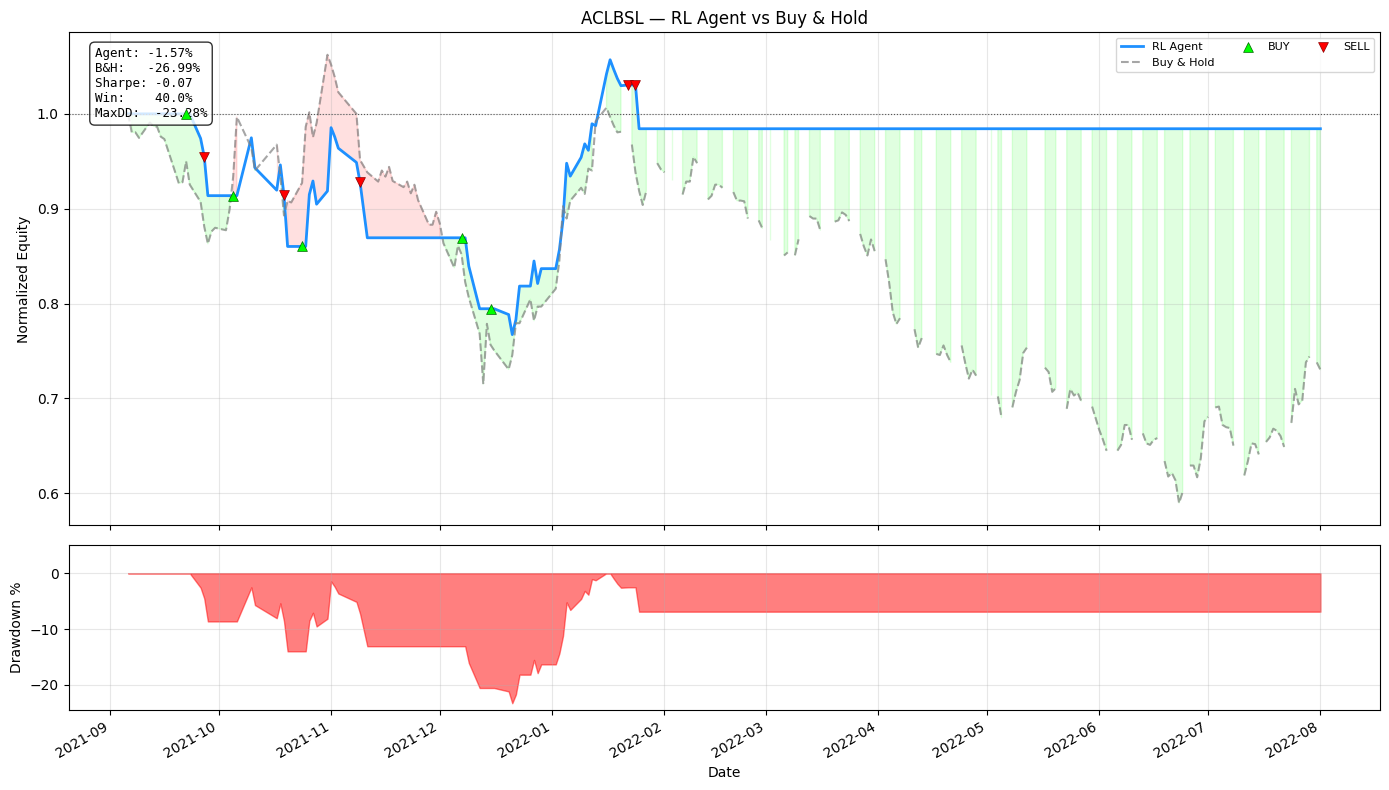

In [94]:
# ── 7a. Equity curve: Agent vs Buy & Hold ──

pv    = traj["portfolio_value"].values.astype(np.float64)
close = traj["close"].values.astype(np.float64)
dates = pd.to_datetime(traj["date"])
agent_eq = pv / pv[0]
bh_eq    = close / close[0]

rmax = np.maximum.accumulate(agent_eq)
dd   = (agent_eq - rmax) / (rmax + 1e-10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

ax1.plot(dates, agent_eq, color="dodgerblue", lw=2, label="RL Agent")
ax1.plot(dates, bh_eq,    color="gray", lw=1.5, ls="--", alpha=0.7, label="Buy & Hold")
ax1.axhline(1.0, color="#555", lw=0.8, ls=":")
ax1.fill_between(dates, agent_eq, bh_eq, where=agent_eq > bh_eq, alpha=0.12, color="lime")
ax1.fill_between(dates, agent_eq, bh_eq, where=agent_eq < bh_eq, alpha=0.12, color="red")

# Buy / sell / forced markers
actions   = traj["action"].values
positions = traj["position"].values
buy_m  = (positions == 0) & (actions == 1)
sell_m = (positions == 1) & (actions == 0)
fl_raw = traj["forced_liquidation"].values if "forced_liquidation" in traj.columns else np.zeros(len(traj), dtype=bool)
fl_m   = np.array([bool(f) if not pd.isna(f) else False for f in fl_raw])
forced_m = (positions == 1) & (actions == 1) & fl_m

if buy_m.any():
    ax1.scatter(dates[buy_m], agent_eq[buy_m], marker="^", color="lime", s=50,
               zorder=5, edgecolors="darkgreen", lw=0.5, label="BUY")
if sell_m.any():
    ax1.scatter(dates[sell_m], agent_eq[sell_m], marker="v", color="red", s=50,
               zorder=5, edgecolors="darkred", lw=0.5, label="SELL")
if forced_m.any():
    ax1.scatter(dates[forced_m], agent_eq[forced_m], marker="x", color="magenta", s=60,
               zorder=5, lw=2, label="FORCED EXIT")

# Stats box
stats = (f"Agent: {metrics['total_return_agent']:+.2%}\n"
         f"B&H:   {metrics['total_return_buyhold']:+.2%}\n"
         f"Sharpe: {metrics['sharpe']:+.2f}\n"
         f"Win:    {metrics['win_rate']:.1%}\n"
         f"MaxDD:  {metrics['max_drawdown']:.2%}")
ax1.text(0.02, 0.97, stats, transform=ax1.transAxes, fontsize=9, va="top",
         fontfamily="monospace", bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))

ax1.set_ylabel("Normalized Equity")
ax1.set_title(f"{EVAL_TICKER} — RL Agent vs Buy & Hold")
ax1.legend(fontsize=8, ncol=3, loc="upper right"); ax1.grid(True, alpha=0.3)

ax2.fill_between(dates, dd * 100, 0, color="red", alpha=0.5)
ax2.set_ylabel("Drawdown %"); ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3); ax2.set_ylim(top=5)

fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(RUN_DIR / f"equity_{EVAL_TICKER}.png", dpi=150, bbox_inches="tight")
log.info(f"Saved equity_{EVAL_TICKER}.png")
plt.show()

17:28:48 | INFO    | Saved signals_ACLBSL.png


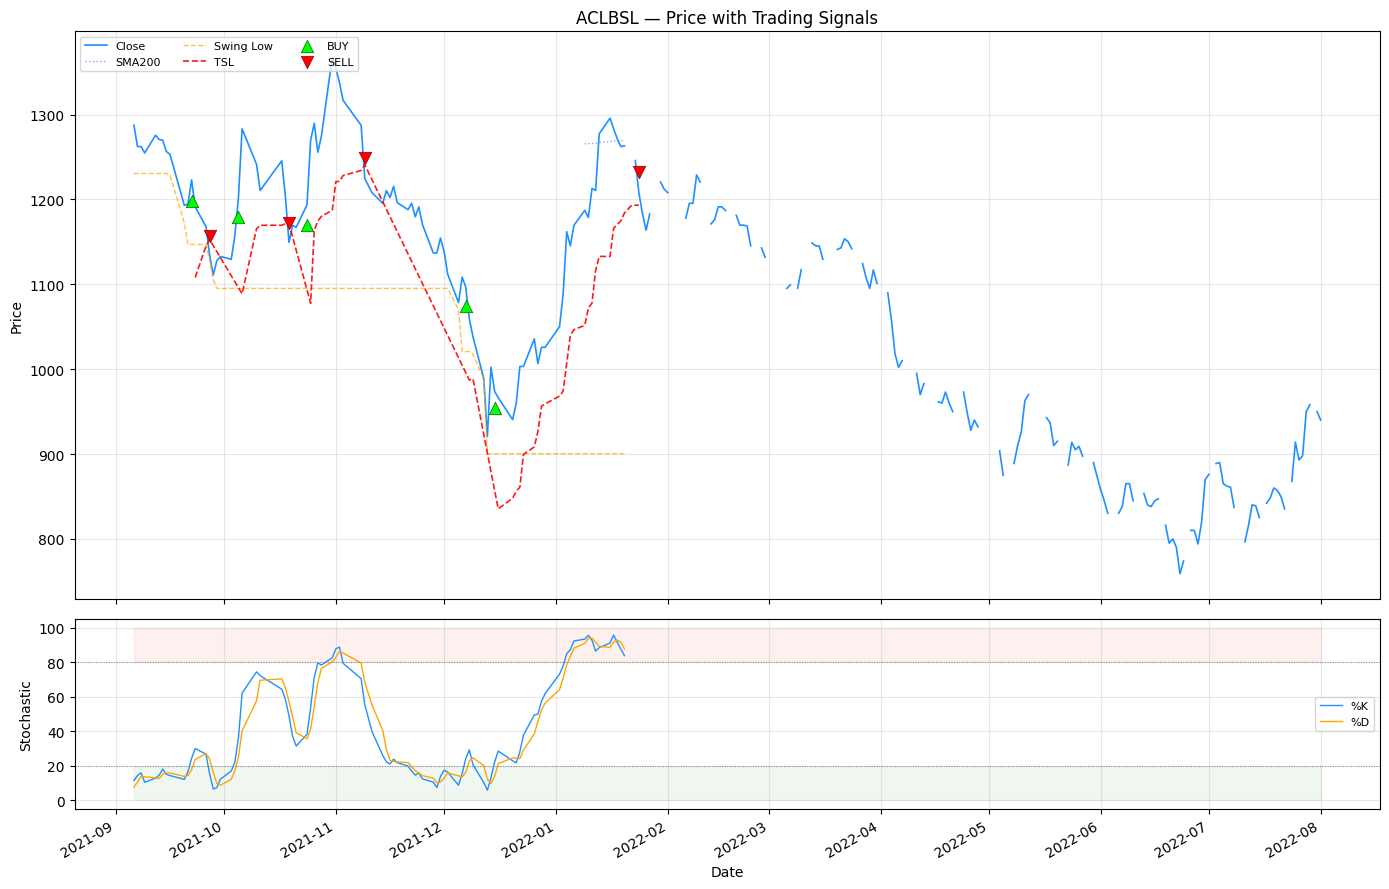

In [95]:
# ── 7b. Price chart with buy/sell signals + stochastic ──

tk = EVAL_TICKER
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

close_vals = traj["close"].values

# Price
ax = axes[0]
ax.plot(dates, close_vals, color="dodgerblue", lw=1.2, label="Close")

# SMA200 + swing low
try:
    sma200 = feat_df.loc[traj["date"].values, (tk, "sma200")].values
    ax.plot(dates, sma200, color="#4488ff", lw=1, ls=":", alpha=0.7, label="SMA200")
except Exception: pass
try:
    psl = feat_df.loc[traj["date"].values, (tk, "protected_swing_low")].values
    ax.plot(dates, psl, color="orange", lw=1, ls="--", alpha=0.7, label="Swing Low")
except Exception: pass

# TSL
tsl = traj["tsl_level"].values
valid_tsl = ~np.isnan(tsl)
if valid_tsl.any():
    ax.plot(dates[valid_tsl], tsl[valid_tsl], color="red", lw=1.2, ls="--", alpha=0.9, label="TSL")

# Markers
if buy_m.any():
    ax.scatter(dates[buy_m], close_vals[buy_m] * 0.98, marker="^", color="lime",
              s=80, zorder=5, edgecolors="darkgreen", lw=0.5, label="BUY")
if sell_m.any():
    ax.scatter(dates[sell_m], close_vals[sell_m] * 1.02, marker="v", color="red",
              s=80, zorder=5, edgecolors="darkred", lw=0.5, label="SELL")
if forced_m.any():
    ax.scatter(dates[forced_m], close_vals[forced_m] * 1.04, marker="x", color="magenta",
              s=100, zorder=5, lw=2, label="FORCED EXIT")

ax.set_ylabel("Price")
ax.set_title(f"{tk} — Price with Trading Signals")
ax.legend(fontsize=8, ncol=3, loc="upper left"); ax.grid(True, alpha=0.3)

# Stochastic panel
ax2 = axes[1]
try:
    pk = feat_df.loc[traj["date"].values, (tk, "pct_k")].values * 100
    pd_ = feat_df.loc[traj["date"].values, (tk, "pct_d")].values * 100
    ax2.plot(dates, pk, color="dodgerblue", lw=1, label="%K")
    ax2.plot(dates, pd_, color="orange", lw=1, label="%D")
    ax2.axhline(20, color="gray", ls=":", lw=0.7)
    ax2.axhline(80, color="gray", ls=":", lw=0.7)
    ax2.fill_between(dates, 0, 20, alpha=0.06, color="green")
    ax2.fill_between(dates, 80, 100, alpha=0.06, color="red")
except Exception: pass
ax2.set_ylabel("Stochastic"); ax2.set_xlabel("Date")
ax2.set_ylim(-5, 105); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(RUN_DIR / f"signals_{tk}.png", dpi=150, bbox_inches="tight")
log.info(f"Saved signals_{tk}.png")
plt.show()

---
## 8 — Multi-Ticker Comparison

In [96]:
eval_tickers = tickers  # all stocks
log.info(f"Multi-ticker eval — {len(eval_tickers)} tickers")
results = []

for tk in eval_tickers:
    try:
        t = run_episode(model, feat_df, valid_start_dates, ticker=tk)
        m = compute_metrics(t)
        m["ticker"] = tk
        results.append(m)
    except Exception as e:
        log.warning(f"  {tk}: SKIPPED — {e}")

results_df = pd.DataFrame(results).set_index("ticker")
log.info(f"Multi-ticker eval complete — {len(results)}/{len(eval_tickers)} succeeded")

# Export results CSV
results_df.to_csv(RUN_DIR / "multi_ticker_results.csv")
log.info(f"Saved multi_ticker_results.csv ({len(results_df)} tickers)")

results_df.style.format({
    "total_return_agent":   "{:+.2%}",
    "total_return_buyhold": "{:+.2%}",
    "excess_return":        "{:+.2%}",
    "sharpe":               "{:+.2f}",
    "max_drawdown":         "{:.2%}",
    "win_rate":             "{:.1%}",
    "exposure_pct":         "{:.1%}",
    "final_pv":             "{:.4f}",
})

17:28:49 | INFO    | Multi-ticker eval — 378 tickers
17:28:49 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:28:49 | INFO    | Eval episode — ticker=ACLBSL, start=2021-09-06, len=252
17:28:49 | INFO    | Eval done — ACLBSL: pv=0.9843, steps=253, buys=48
17:28:49 | INFO    | Trade ledger — 5 round-trips, 0 forced exits
17:28:49 | INFO    | Metrics — ret=-0.0157, sharpe=-0.07, maxDD=-23.28%, trades=5, winrate=40.0%
17:28:49 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:28:49 | INFO    | Eval episode — ticker=ADBL, start=2012-06-06, len=252
17:28:50 | INFO    | Eval done — ADBL: pv=1.0000, steps=253, buys=0
17:28:50 | INFO    | Trade ledger — 0 round-trips, 0 forced exits
17:28:50 | INFO    | Metrics — ret=+0.0000, sharpe=+0.00, maxDD=0.00%, trades=0, winrate=0.0%
17:28:50 | INFO    | NepseEnv init — 378 tickers, ep_len=252, obs=(7,)
17:28:50 | INFO    | Eval episode — ticker=AHL, start=2024-02-01, len=252
17:28:50 | INFO    | Eval done — AHL: pv=1.000

,total_return_agent,total_return_buyhold,excess_return,sharpe,max_drawdown,num_trades,win_rate,profit_factor,exposure_pct,forced_liquidations,final_pv
ticker,,,,,,,,,,,
ACLBSL,-1.57%,-26.99%,+25.42%,-0.07,-23.28%,5,40.0%,1.311700,19.1%,1,0.9843
ADBL,+0.00%,+39.93%,-39.93%,+0.00,0.00%,0,0.0%,0.000000,0.0%,0,1.0000
AHL,+0.00%,+77.75%,-77.75%,+0.00,0.00%,0,0.0%,0.000000,0.0%,0,1.0000
AHPC,-6.27%,+0.81%,-7.08%,-1.91,-6.33%,3,0.0%,0.000000,2.8%,0,0.9373
AIL,-44.12%,+nan%,+nan%,-2.13,-51.76%,12,25.0%,nan,43.6%,3,0.5588
AKJCL,+9.47%,+41.95%,-32.48%,+0.43,-17.60%,13,38.5%,3.993900,55.6%,3,1.0947
AKPL,-22.97%,-19.82%,-3.15%,-1.11,-41.00%,15,26.7%,nan,49.2%,2,0.7703
ALBSL,+108.72%,+264.53%,-155.81%,+1.69,-25.33%,12,58.3%,4.396900,63.5%,2,2.0872
ALICL,-1.75%,+12.78%,-14.53%,-0.83,-2.78%,1,0.0%,0.000000,3.6%,0,0.9825


---

**Done.** Everything runs from this single notebook — no external modules needed.